# **Chronic Kidney Disease Dataset Project**
### *by Imtiaz Ali*  
**BS Mathematics & Statistics** | **Machine Learning Engineer**

---

#### **Project Task:**
Assigned by **Professor Xuejing Zhao**  
*Institute of Probability and Statistics, Lanzhou University*

---


## Introduction

In this project, I worked with a dataset of chronic kidney disease (CKD) patients. The goal was to preprocess, analyze, and build predictive models to better understand the factors associated with CKD and predict both CKD status and Glomerular Filtration Rate (GFR).

## Contents

1. *Data Preprocessing & Univariate Analysis*
   - Handling missing values and inconsistencies.
   - Encoding categorical variables (Albumin, Sugar Urine, Specific Gravity, etc.).
   - Analyzing each variable individually.
   - Gaining insights into the distribution and properties of the data.

2. *Correlation Analysis*
   - Identifying relationships between variables.
   - Selecting the most relevant features using a correlation threshold.

3. *Logistic Regression Model*
   - Target variable: CKD status (0: non-CKD, 1: CKD).
   - Model performance evaluation.

4. *Linear Regression Model*
   - Predicting GFR (Glomerular Filtration Rate).
   - Performance analysis.

5. *Random Forest Classifier for Feature Selection*
   - Identifying the most influential variables for CKD prediction.


6. *Random Forest Classifier Model*
   - Building a prediction model for CKD status.
   - Achieving 100% accuracy (got overfitting due to small dataset size).

In [1]:
import pandas as pd

# Load your data
df = pd.read_csv('ckd-dataset-v2.csv')

In [2]:
df.head(10)

,bp (Diastolic),bp limit,sg,al,class,rbc,su,pc,pcc,ba,...,htn,dm,cad,appet,pe,ane,grf,stage,affected,age
0,discrete,discrete,discrete,discrete,discrete,discrete,discrete,discrete,discrete,discrete,...,discrete,discrete,discrete,discrete,discrete,discrete,discrete,discrete,discrete,discrete
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,class,meta
2,0,0,1.019 - 1.021,1 - 1,ckd,0,< 0,0,0,0,...,0,0,0,0,0,0,≥ 227.944,s1,1,< 12
3,0,0,1.009 - 1.011,< 0,ckd,0,< 0,0,0,0,...,0,0,0,0,0,0,≥ 227.944,s1,1,< 12
4,0,0,1.009 - 1.011,≥ 4,ckd,1,< 0,1,0,1,...,0,0,0,1,0,0,127.281 - 152.446,s1,1,< 12
5,1,1,1.009 - 1.011,3 - 3,ckd,0,< 0,0,0,0,...,0,0,0,0,0,0,127.281 - 152.446,s1,1,< 12
6,0,0,1.015 - 1.017,< 0,ckd,0,< 0,0,0,0,...,0,1,0,1,1,0,127.281 - 152.446,s1,1,12 - 20
7,1,1,≥ 1.023,< 0,notckd,0,< 0,0,0,0,...,0,0,0,0,0,0,102.115 - 127.281,s1,0,12 - 20
8,0,0,1.019 - 1.021,3 - 3,ckd,0,< 0,0,0,0,...,1,1,0,0,0,0,177.612 - 202.778,s1,1,12 - 20
9,0,0,1.019 - 1.021,< 0,ckd,0,< 0,0,0,0,...,0,0,0,0,0,0,26.6175 - 51.7832,s4,1,12 - 20


### Remove first two unusual rows

In [2]:
df.drop(df.head(2).index, inplace=True)

In [4]:
df.head(11)

,bp (Diastolic),bp limit,sg,al,class,rbc,su,pc,pcc,ba,...,htn,dm,cad,appet,pe,ane,grf,stage,affected,age
2,0,0,1.019 - 1.021,1 - 1,ckd,0,< 0,0,0,0,...,0,0,0,0,0,0,≥ 227.944,s1,1,< 12
3,0,0,1.009 - 1.011,< 0,ckd,0,< 0,0,0,0,...,0,0,0,0,0,0,≥ 227.944,s1,1,< 12
4,0,0,1.009 - 1.011,≥ 4,ckd,1,< 0,1,0,1,...,0,0,0,1,0,0,127.281 - 152.446,s1,1,< 12
5,1,1,1.009 - 1.011,3 - 3,ckd,0,< 0,0,0,0,...,0,0,0,0,0,0,127.281 - 152.446,s1,1,< 12
6,0,0,1.015 - 1.017,< 0,ckd,0,< 0,0,0,0,...,0,1,0,1,1,0,127.281 - 152.446,s1,1,12 - 20
7,1,1,≥ 1.023,< 0,notckd,0,< 0,0,0,0,...,0,0,0,0,0,0,102.115 - 127.281,s1,0,12 - 20
8,0,0,1.019 - 1.021,3 - 3,ckd,0,< 0,0,0,0,...,1,1,0,0,0,0,177.612 - 202.778,s1,1,12 - 20
9,0,0,1.019 - 1.021,< 0,ckd,0,< 0,0,0,0,...,0,0,0,0,0,0,26.6175 - 51.7832,s4,1,12 - 20
10,0,0,≥ 1.023,< 0,notckd,0,< 0,0,0,0,...,0,0,0,0,0,0,26.6175 - 51.7832,s4,0,20 - 27
11,1,2,1.009 - 1.011,≥ 4,ckd,0,< 0,1,1,1,...,0,0,0,0,0,1,51.7832 - 76.949,s3,1,20 - 27


In [5]:
df.shape

(200, 29)

# Column Descriptions:
1. bp (Diastolic)  
2. bp limit  
3. sg (Specific Gravity)  
4. al (Albumin Level)  
5. claas  
6. RBC (Red Blood Cells)  
7. SU (Sugar in Urine)  
8. PC (Pus Cells)  
9. PCC (Pus Cell Clumps)  
10. BA (Bacteria)  
11. BGR (Blood Glucose Random)  
12. BU (Blood Urea)  
13. SOD (Sodium)  
14. SC (Serum Creatinine)  
15. POT (Potassium)  
16. Hemo (Hemoglobin)  
17. PCV (Packed Cell Volume)  
18. RBC (Red Blood Cell)  
19. WBC (White Blood Cell)  
20. Hypertension (HTN)  
21. Diabetes Mellitus (DM)  
22. Coronary Artery Disease (CAD)  
23. Appetite  
24. Pulmonary Embolism (PE)  
25. Anemia (ANE)  
26. Glomerular Filtration Rate (GFR)  
27. Stage  
28. Affected  
29. Age



In [6]:
# Check for missing values
print(df.isnull().sum())

bp (Diastolic)    0
bp limit          0
sg                0
al                0
class             0
rbc               0
su                0
pc                0
pcc               0
ba                0
bgr               0
bu                0
sod               0
sc                0
pot               0
hemo              0
pcv               0
rbcc              0
wbcc              0
htn               0
dm                0
cad               0
appet             0
pe                0
ane               0
grf               0
stage             0
affected          0
age               0
dtype: int64


## It has no missing values

# Checking columns category

In [7]:
# Get numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Numerical Columns:")
print(numerical_cols)

# Get categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
Index([], dtype='object')

Categorical Columns:
Index(['bp (Diastolic)', 'bp limit', 'sg', 'al', 'class', 'rbc', 'su', 'pc',
       'pcc', 'ba', 'bgr', 'bu', 'sod', 'sc', 'pot', 'hemo', 'pcv', 'rbcc',
       'wbcc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'grf', 'stage',
       'affected', 'age'],
      dtype='object')


## Here we see there are no numerical columns

##  View data summary


In [8]:
df.describe()

,bp (Diastolic),bp limit,sg,al,class,rbc,su,pc,pcc,ba,...,htn,dm,cad,appet,pe,ane,grf,stage,affected,age
count,200,200,200,200,200,200,200,200,200,200,...,200,200,200,200,200,200,200,200,200,200
unique,2,3,5,5,2,2,6,2,2,2,...,2,2,2,2,2,2,11,5,2,10
top,1,0,1.019 - 1.021,< 0,ckd,0,< 0,0,0,0,...,0,0,0,0,0,0,< 26.6175,s1,1,59 - 66
freq,108,95,75,116,128,175,170,155,173,189,...,122,130,178,160,165,168,68,54,128,48


## Visualize and then analyize the columns it will help us getting more understanding of features then we will be able to work on this data set

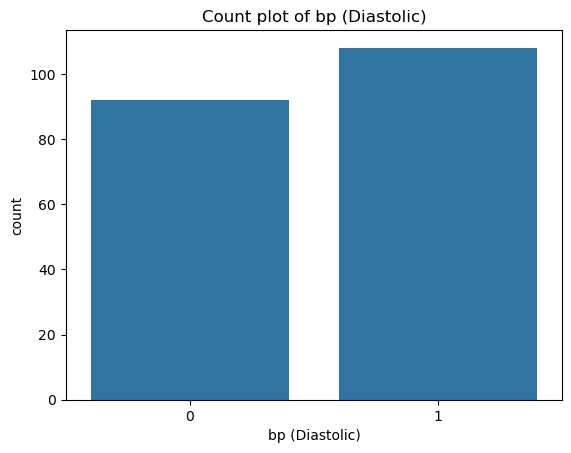

In [3]:

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='bp (Diastolic)', data=df)
plt.title('Count plot of bp (Diastolic)')
plt.show()

# Aanlysis of the above visualization of bp (Diastolic) column

Represents diastolic blood pressure, 

The discrete values 
1 : (High) 
0 : (Normal)
more than 100  are high bp patients.

### Medical Interpretation:

- 0: Normal or negligible levels, indicating healthy kidney function.
- 1: Slightly elevated levels, may suggest early kidney dysfunction.

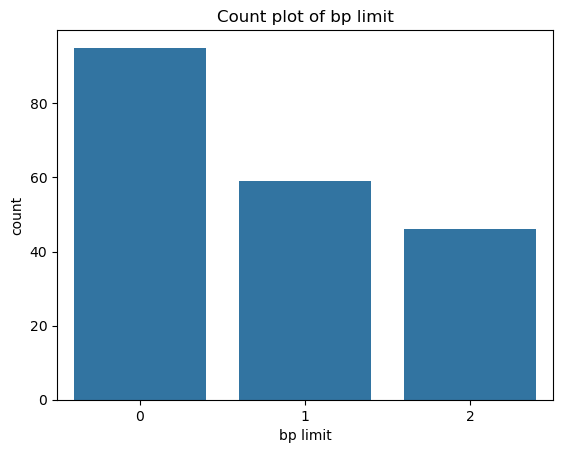

In [10]:
sns.countplot(x='bp limit', data=df)
plt.title('Count plot of bp limit')
plt.show()

## Analysis of BP Limit Column

- 0: more than 80 instances - Normal blood pressure
- 1: nearly 60 instances - Mild hypertension
- 2: more than 40 instances - Moderate hypertension

### Medical Interpretation:

- 0: Normal blood pressure, indicating healthy cardiovascular function.
- 1: Mild hypertension, may suggest early cardiovascular disease or kidney dysfunction.
- 2: Moderate hypertension, indicating moderate cardiovascular disease or kidney damage.


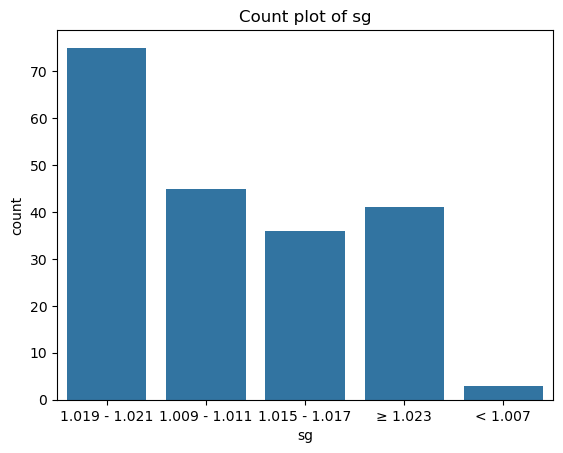

In [11]:
sns.countplot(x='sg', data=df)
plt.title('Count plot of sg')
plt.show()

## Analysis of specific gravity(sg) column

1.019 - 1.021: more 70 instances (most common range, normal to slightly concentrated urine)

1.009 - 1.011: more than 40 instances (indicative of diluted urine)

1.015 - 1.017: more than 20 instances (moderate concentration)

≥ 1.023: nearly 40 instances (highly concentrated urine)

< 1.007: 3 instances (very dilute urine)


| Specific Gravity Range | Category        | Ordinal Value |
|------------------------|-----------------|---------------|
| 1.019 - 1.021          | Elevated        | 1             |
| 1.009 - 1.011          | Normal          | 2             |
| ≥ 1.023                | Highly Elevated | 3             |
| 1.015 - 1.017          | Slightly Elevated| 4            |
| < 1.007                | Low             | 0             |



### Medical Significance:

Normal Range: 

1.005 to 1.030.

Frequent Range:

1.019 - 1.021 (most common) suggests normal to slightly concentrated urine.

High Specific Gravity (≥ 1.023):

potentially indicating dehydration or poor kidney concentration ability.

Low Specific Gravity (< 1.007):

potentially indicating overhydration or poor concentration ability due to kidney damage.

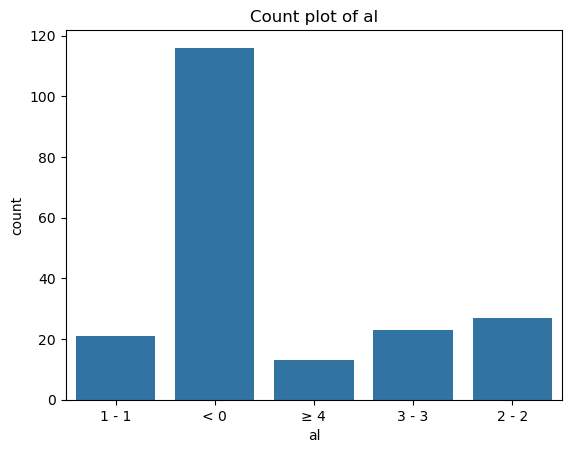

In [12]:
sns.countplot(x='al', data=df)
plt.title('Count plot of al')
plt.show()

## Analysis of the albumin column

1 - 1: more than 20 instances (slightly elevated albumin levels)

< 0: more than 100 instances (normal or negligible albumin levels, healthy kidney function)

≥ 4: nearly 10 instances (very high albuminuria, severe kidney damage)

3 - 3: more than 20 instances (high albuminuria)

2 - 2: 30 instances (moderate albuminuria)




Categories:

1. Severely Low: < 0
2. Low: 1
3. Normal: 2
4. High: 3
5. Very High: ≥ 4



| Albumin Range | Category | Ordinal Value |
| --- | --- | --- |
| < 0 | Severely Low | 0.0 |
| 1 | Low | 1.0 |
| 2 | Normal | 2.0 |
| 3 | High | 3.0 |
| ≥ 4 | Very High | 4.0 |



### Medical Interpretation:

< 0    These indicate normal or no detectable albumin in the urine, suggesting healthy kidney function.

1 - 1  Slightly elevated albumin levels may suggest early signs of kidney dysfunction.

2 - 2  Moderate albuminuria, which indicates a significant amount of albumin in the urine, often correlates with moderate kidney damage.

3 - 3  High albuminuria, suggesting advanced kidney damage, often seen in progressive CKD.

≥ 4    Very high albumin levels, indicating severe kidney damage and a high risk of CKD progression.

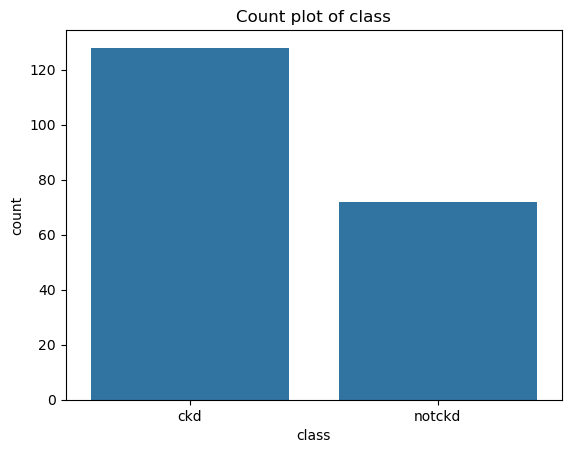

In [13]:
sns.countplot(x='class', data=df)
plt.title('Count plot of class')
plt.show()

## claas column
This is the Classification Column:

- CKD: Chronic Kidney Disease

- notckd: No Chronic Kidney Disease


| Class | Ordinal Value |
| --- | --- |
| notckd | 0 |
| ckd | 1 |



## This will be our target feature for a Purpose: Predict whether a patient has Chronic Kidney Disease (CKD) or not


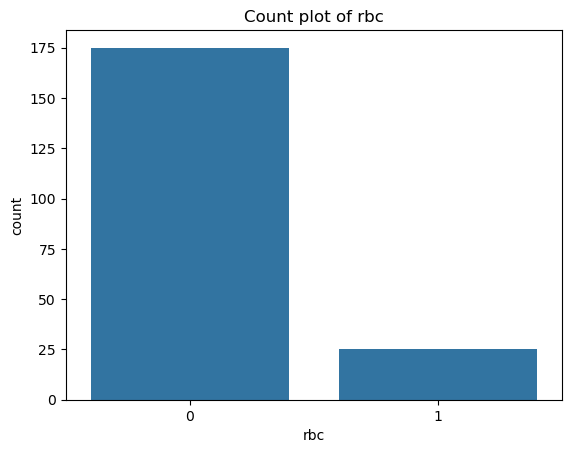

In [14]:
sns.countplot(x='rbc', data=df)
plt.title('Count plot of rbc')
plt.show()

## Analysis of RBC (Red Blood Cells) Column

- 0:   more than 170 instances  - Normal or negligible levels
  
- 1:   less instances - Slightly elevated levels

### Medical Interpretation:

- 0   : Normal or negligible levels, indicating healthy kidney function.
- 1   : Slightly elevated levels, may suggest early kidney dysfunction.


    - 0: Normal RBC count
    - 1: Abnormal RBC count (hematuria)

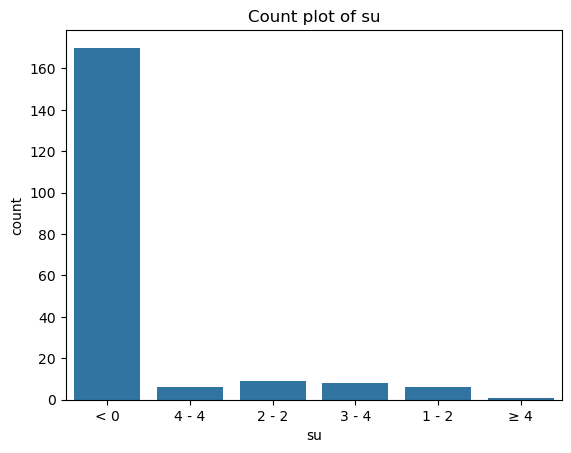

In [15]:
sns.countplot(x='su', data=df)
plt.title('Count plot of su')
plt.show()

##  Analysis of SU (Sugar in Urine) Column


- < 0: more than 150 instances - Normal or negligible levels
  
- 1 - 2: less instances - Slightly elevated levels
  
- 2 - 2: less instances - Moderate levels
  
- 3 - 4: less instances - High levels
  
- 4 - 4: less instances - Very high levels
  
- ≥ 4:   less instances  - Extremely high levels


| Sugar Urea Range | Category | Ordinal Value |
| --- | --- | --- |
| < 0 | Negative | 0.0 |
| 1-2 | Trace | 1.0 |
| 2-2 | Positive | 2.0 |
| 3-4 | Highly Positive | 3.0 |
| ≥ 4 | Very Highly Positive | 4.0 |




### Medical Interpretation:

- < 0   : Normal or negligible levels, indicating healthy kidney function.
  
- 1 - 2 : Slightly elevated levels, may suggest early kidney dysfunction.
  

- 2 - 2 : Moderate levels, indicating moderate kidney damage.

- 3 - 4 : High levels, suggesting advanced kidney damage and progressive CKD.

- 4 - 4 : Very high levels, indicating severe kidney damage.

- ≥ 4   : Extremely high levels, high risk of CKD progression.


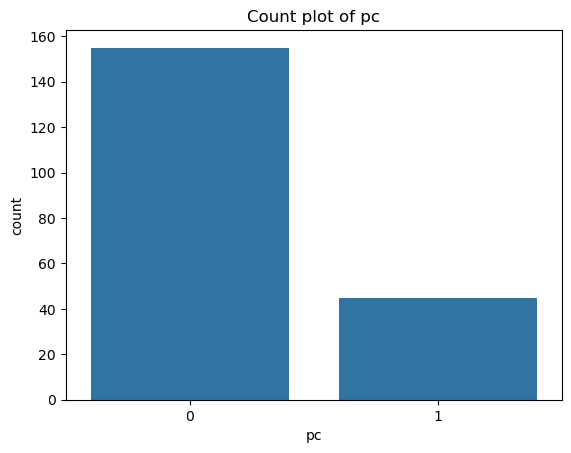

In [16]:
sns.countplot(x='pc', data=df)
plt.title('Count plot of pc')
plt.show()

##  Analysis of PC (Pus Cells) Column


- 0: more than 150 instances  - Normal or negligible levels
  
- 1: less instances - Slightly elevated levels

### Medical Interpretation:

- 0 : Normal or negligible levels, indicating healthy kidney function.
  
- 1 : Slightly elevated levels, may suggest early kidney dysfunction.

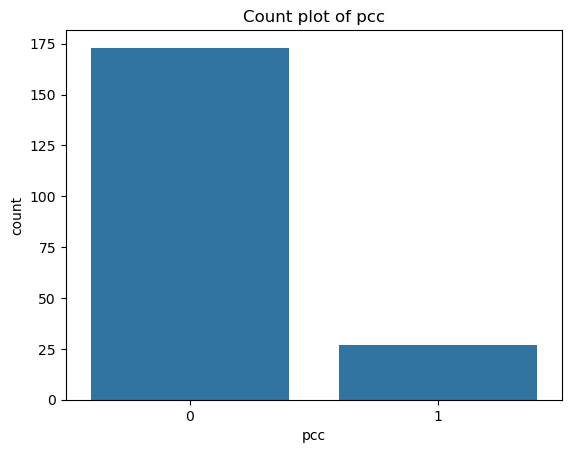

In [17]:
sns.countplot(x='pcc', data=df)
plt.title('Count plot of pcc')
plt.show()

## Analysis of the PCC (Pus Cell Clumps) Column


- 0: more than 150 instances  - Normal or negligible levels


- 1:  less instances        - Slightly elevated levels

  

### Medical Interpretation:


- 0  : Normal or negligible levels, indicating healthy kidney function.

- 1  : Slightly elevated levels, may suggest early kidney dysfunction.


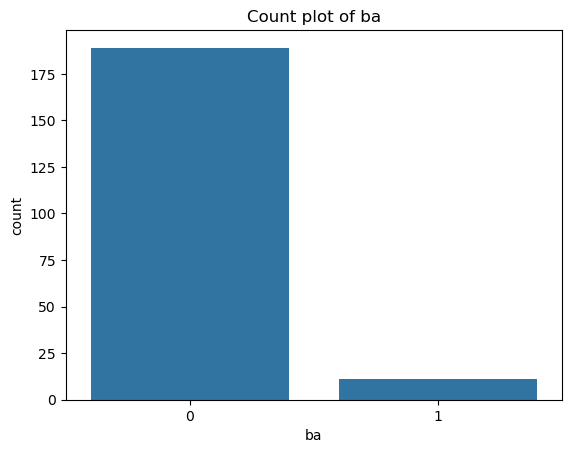

In [18]:
sns.countplot(x='ba', data=df)
plt.title('Count plot of ba')
plt.show()

## Analysis of BA (Bacteria) Column


- 0: more than 170 instances  - Normal or negligible levels
- 1: less instances           - Slightly elevated levels

### Medical Interpretation:

- 0 :   Normal or negligible levels, indicating healthy kidney function.
- 1 :   Slightly elevated levels, may suggest early kidney dysfunction.

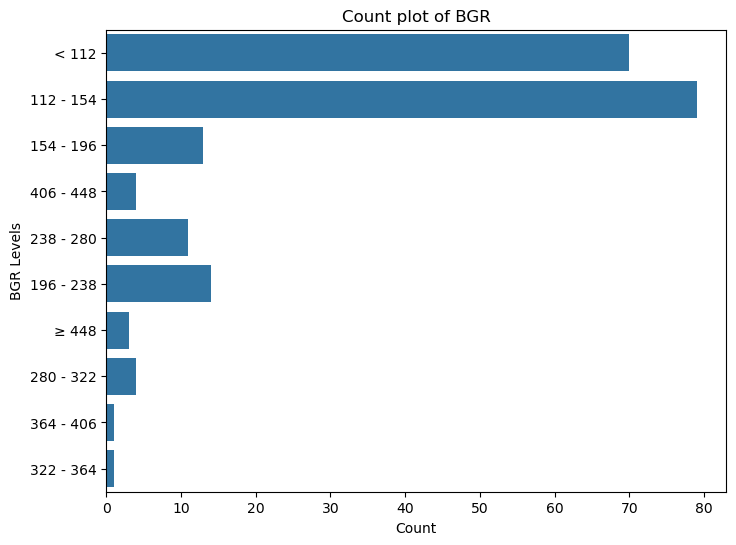

In [19]:
# Create count plot with vertical bars for values and horizontal bars for counts
plt.figure(figsize=(8,6))
sns.countplot(y='bgr', data=df) 
# or sns.countplot(x='bgr', data=df, orient='h')

plt.title('Count plot of BGR')
plt.xlabel('Count')
plt.ylabel('BGR Levels')
plt.show()

## Analysis of BGR (Blood Glucose Random) column



- < 112:   nearly 70 instances  - Below normal range
  
- 112-154: nearly  80 instances  - Normal range
  
- 154-196: nearly 20 instances  - Slightly elevated
- 
- 196-238: nearly  10 instances (6.4% of total) - Elevated
  
- 238-280: less instances - Highly elevated
  
- 280-322: less instances - Very highly elevated
  

- 322-364: less instances - Extremely elevated

- ≥ 448:   less instances - Severely elevated


| Blood Glucose Range | Category | Ordinal Value |
| --- | --- | --- |
| < 112 | Low | 0.0 |
| 112-154 | Normal | 1.0 |
| 154-196 | Elevated | 2.0 |
| 196-238 | High | 3.0 |
| 238-280 | Very High | 4.0 |
| 280-322 | Extremely High | 5.0 |
| 322-364 | Severely Elevated | 6.0 |
| 364-406 | Dangerously High | 7.0 |
| 406-448 | Critically High | 8.0 |
| ≥ 448 | Life-Threatening | 9.0 |



### Medical Interpretation:


- Blood glucose (bgr) levels indicate varying degrees of glycemic control.

- Normal range (112-154): Healthy glucose levels.

- Below normal (< 112): Hypoglycemia or low glucose levels.

- Elevated ranges: Hyperglycemia or high glucose levels, potentially indicating diabetes or insulin resistance.

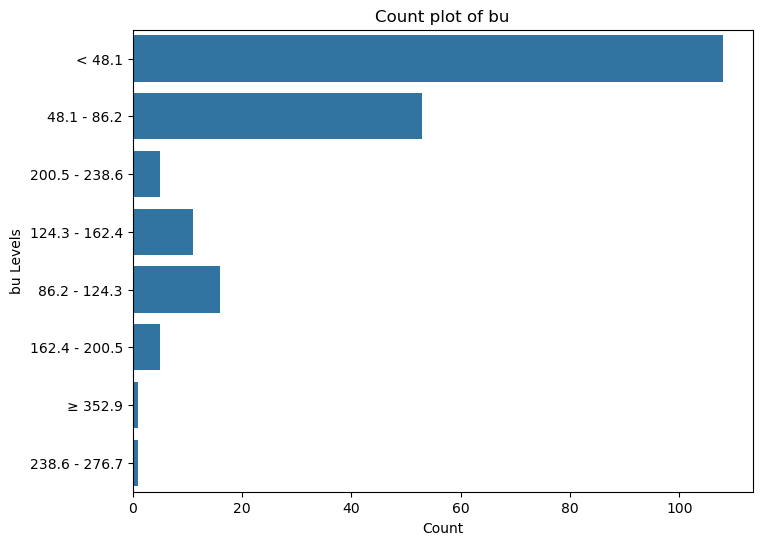

In [20]:
# Create count plot with vertical bars for values and horizontal bars for counts
plt.figure(figsize=(8,6))
sns.countplot(y='bu', data=df) 
# or sns.countplot(x='bgr', data=df, orient='h')

plt.title('Count plot of bu')
plt.xlabel('Count')
plt.ylabel('bu Levels')
plt.show()

## Analysis of Blood Urea BU column


- < 48.1: nearly 120 instances - Below normal range

- 48.1-86.2: nearly 60 instances - Normal range

- 86.2-124.3: nearly 20 instances - Slightly elevated

- 124.3-162.4: nearly 15 instances - Elevated

- 162.4-200.5: nearly 10 instances - Highly elevated

- 200.5-238.6: nearly 5 instances - Very highly elevated

- ≥ 352.9: less than 5 instances - Severely elevated

- 238.6-276.7: less than 5 instances - Extremely elevated



| Blood Urea Range | Category | Ordinal Value |
| --- | --- | --- |
| < 48.1 | Low | 0.0 |
| 48.1 - 86.2 | Normal | 1.0 |
| 86.2 - 124.3 | Elevated | 2.0 |
| 124.3 - 162.4 | High | 3.0 |
| 162.4 - 200.5 | Very High | 4.0 |
| 200.5 - 238.6 | Extremely High | 5.0 |
| 238.6 - 276.7 | Severely Elevated | 6.0 |
| ≥ 352.9 | Life-Threatening | 7.0 |




### Medical Interpretation:

- Blood urea (BU) levels indicate varying degrees of renal function.

- Normal range (48.1-86.2): Healthy renal function.

- Below normal (< 48.1): Low urea levels, potentially indicating liver disease or malnutrition.

- Elevated ranges: Hyperuremia or high urea levels, potentially indicating renal disease, dehydration, or heart failure.


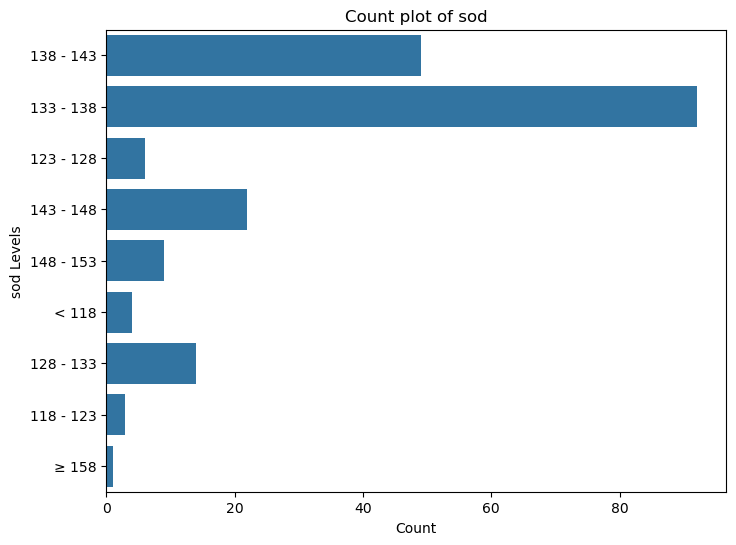

In [21]:
plt.figure(figsize=(8,6))
sns.countplot(y='sod', data=df) 
# or sns.countplot(x='bgr', data=df, orient='h')

plt.title('Count plot of sod')
plt.xlabel('Count')
plt.ylabel('sod Levels')
plt.show()

### Analysis of SOD Column (Serum Sodium Levels)


- *138 - 143: Nearly 50 instances - **Upper normal range*  
 
- *133 - 138: Nearly 100 instances - **Normal range*  
  
- *123 - 128: less instances - **Slightly low sodium*  
 
- *143 - 148: Nearly 30 instances - **Slightly elevated sodium*  
 
- *118 - 123: less instances - **Low sodium*  

- *123 - 128: less instances - **Slightly low sodium*  

- *128 - 133: less instances - **Lower end of normal range*  
 
- *148 - 153: less instances - **Elevated sodium*  

- *≥ 158: Less than 5 instances - **Severely elevated sodium*  



| Serum Sodium Range | Category | Ordinal Value |
| --- | --- | --- |
| < 118 | Severely Low | 0.0 |
| 118-123 | Low | 1.0 |
| 123-128 | Borderline Low | 2.0 |
| 128-133 | Normal (Lower) | 3.0 |
| 133-138 | Normal | 4.0 |
| 138-143 | Normal (Higher) | 5.0 |
| 143-148 | Elevated | 6.0 |
| 148-153 | High | 7.0 |
| ≥ 158 | Severely Elevated | 8.0 |

  
### Medical Interpretation:

- *Normal range (133-143)*: Sodium levels in this range are associated with normal kidney.
- *Low sodium levels (< 133)*: Hyponatremia.

- *Elevated sodium levels (> 143)*: Hypernatremia.


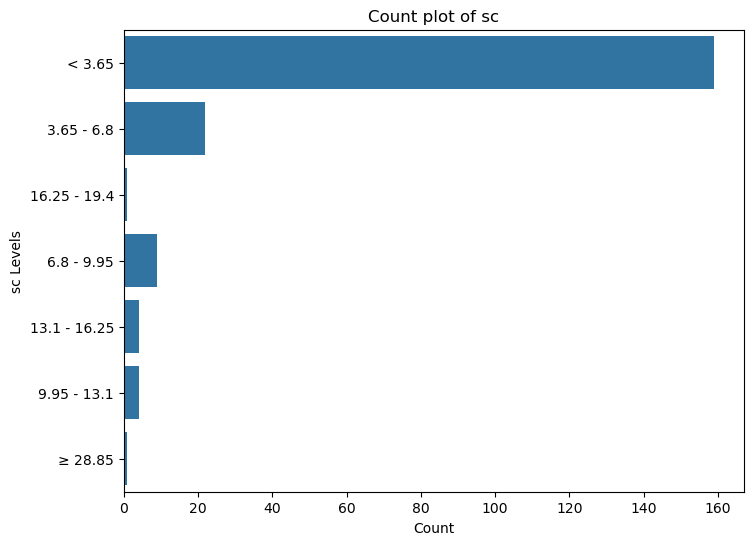

In [22]:
plt.figure(figsize=(8,6))
sns.countplot(y='sc', data=df) 
# or sns.countplot(x='bgr', data=df, orient='h')

plt.title('Count plot of sc')
plt.xlabel('Count')
plt.ylabel('sc Levels')
plt.show()

## Analysis of Serum chloride SC column

- < 3.65: more than 140 instances - Below normal range

- 3.65-6.8: nearly 20 instances - Low normal

- 16.25-19.4: nearly 1 instance - Highly elevated

- 6.8-9.95: nearly 10 instances - Normal range

- 13.1-16.25: nearly 5 instances - Elevated

- 9.95-13.1: nearly 5 instances - Slightly elevated

- ≥ 28.85: less than 1 instance - Severely elevated


| Serum Chloride Range | Category | Ordinal Value |
| --- | --- | --- |
| < 3.65 | Severely Low | 0.0 |
| 3.65 - 6.8 | Low | 1.0 |
| 6.8 - 9.95 | Borderline Low | 2.0 |
| 9.95 - 13.1 | Normal (Lower) | 3.0 |
| 13.1 - 16.25 | Normal | 4.0 |
| 16.25 - 19.4 | Normal (Higher) | 5.0 |
| ≥ 28.85 | Severely Elevated | 6.0 |




### Medical Interpretation:

- Serum chloride (SC) levels indicate varying degrees of electrolyte balance.

- Normal range (6.8-9.95): Healthy electrolyte levels.

- Below normal (< 3.65): Hypochloremia, potentially indicating dehydration, metabolic alkalosis, or renal disease.

- Elevated ranges: Hyperchloremia, potentially indicating dehydration, metabolic acidosis, or respiratory alkalosis.


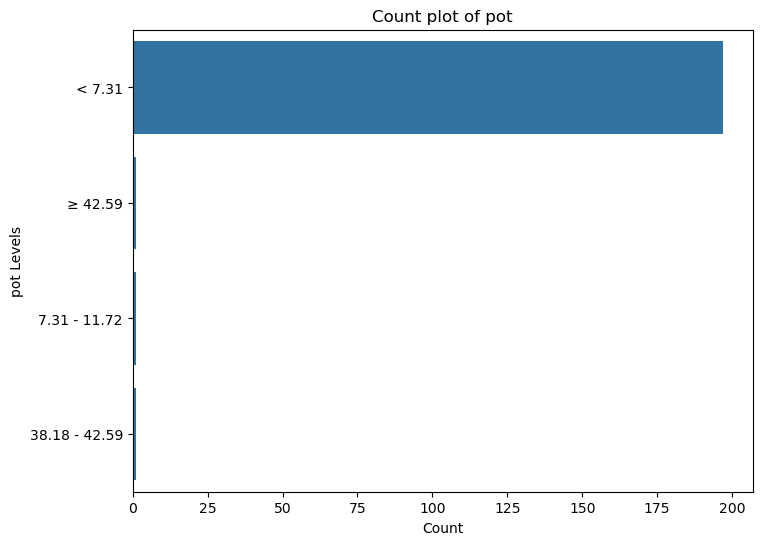

In [23]:
plt.figure(figsize=(8,6))
sns.countplot(y='pot', data=df) 
# or sns.countplot(x='bgr', data=df, orient='h')

plt.title('Count plot of pot')
plt.xlabel('Count')
plt.ylabel('pot Levels')
plt.show()

## Analysis of POT(Potassium)  column

- < 7.31: nearly 200 instances - Below normal range

-  others are very less instances


| Potassium Range | Category | Ordinal Value |
| --- | --- | --- |
| < 7.31 | Severely Low | 0.0 |
| 7.31 - 11.72 | Low | 1.0 |
| 38.18 - 42.59 | Elevated | 2.0 |
| ≥ 42.59 | Severely Elevated | 3.0 |



### Medical Interpretation:

- Serum potassium (POT) levels indicate varying degrees of electrolyte balance.

- Normal range (3.5-5.5): Healthy electrolyte levels.

- Below normal (< 7.31): Hypokalemia.

- Elevated ranges: Hyperkalemia.

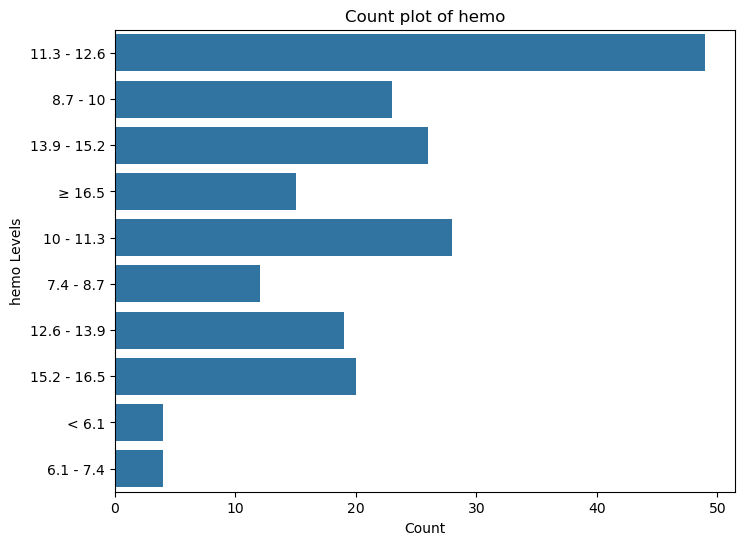

In [24]:
plt.figure(figsize=(8,6))
sns.countplot(y='hemo', data=df) 
# or sns.countplot(x='bgr', data=df, orient='h')

plt.title('Count plot of hemo')
plt.xlabel('Count')
plt.ylabel('hemo Levels')
plt.show()

## Analysis of HEMO(Hemoglobin) column


- 11.3-12.6: nearly 50 instances - Normal range

- 8.7-10: nearly 25 instances - Normal range

- 13.9-15.2: nearly 25 instances - Normal range

- ≥ 16.5: nearly 15 instances - Severely elevated

- 15.2-16.5: nearly 20 instances - Elevated

- other instances are less


| Hemoglobin Range | Category | Ordinal Value |
| --- | --- | --- |
| < 6.1 | Severely Low | 0.0 |
| 6.1 - 7.4 | Low | 1.0 |
| 7.4 - 8.7 | Borderline Low | 2.0 |
| 8.7 - 10 | Mildly Low | 3.0 |
| 10 - 11.3 | Normal (Lower) | 4.0 |
| 11.3 - 12.6 | Normal | 5.0 |
| 12.6 - 13.9 | Normal (Higher) | 6.0 |
| 13.9 - 15.2 | Elevated | 7.0 |
| 15.2 - 16.5 | High | 8.0 |
| ≥ 16.5 | Severely Elevated | 9.0 |



Medical Interpretation:

- Hemoglobin (HEMO) levels indicate varying degrees of anemia or polycythemia.

- Normal range (8.7-15.2): Healthy red blood cell levels.

- Below normal (< 8.7): Anemia, potentially indicating iron deficiency, vitamin deficiency, or chronic disease.

- Elevated ranges: Polycythemia, potentially indicating dehydration, hypoxia, or bone marrow disorders.


In [25]:
df['hemo'].unique()

array(['11.3 - 12.6', '8.7 - 10', '13.9 - 15.2', '≥ 16.5', '10 - 11.3',
       '7.4 - 8.7', '12.6 - 13.9', '15.2 - 16.5', '< 6.1', '6.1 - 7.4'],
      dtype=object)

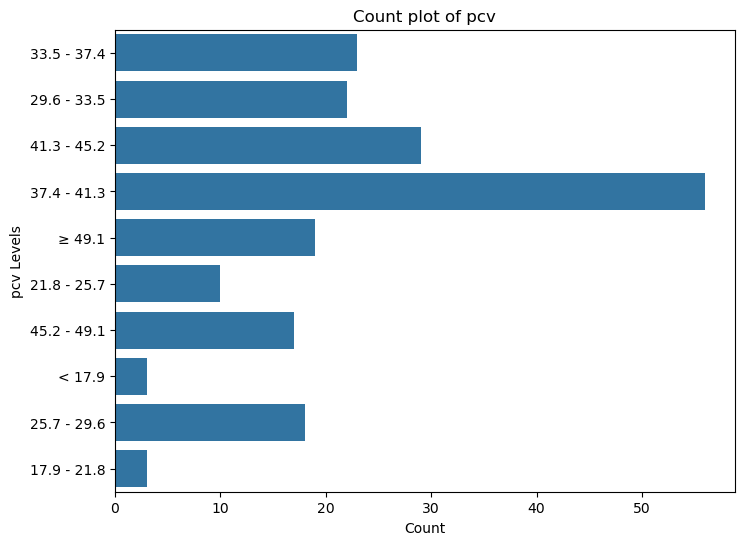

In [26]:
plt.figure(figsize=(8,6))
sns.countplot(y='pcv', data=df) 
# or sns.countplot(x='bgr', data=df, orient='h')

plt.title('Count plot of pcv')
plt.xlabel('Count')
plt.ylabel('pcv Levels')
plt.show()

## Analysis PCV(Packed Cell Volume) column


- 33.5-37.4: nearly 25 instances - Normal range

- 37.4-41.3: more than 50 instances - Normal range

- 41.3-45.2: nearly 30 instances - Elevated

- 29.6-33.5: nearly 20 instances - Normal range

- 21.8-25.7: nearly 10 instances - Below normal

- 25.7-29.6: nearly 15 instances - Low normal



| Packed Cell Volume Range | Category | Ordinal Value |
| --- | --- | --- |
| < 17.9 | Severely Low | 0.0 |
| 17.9 - 21.8 | Low | 1.0 |
| 21.8 - 25.7 | Borderline Low | 2.0 |
| 25.7 - 29.6 | Low Normal | 3.0 |
| 29.6 - 33.5 | Normal (Lower) | 4.0 |
| 33.5 - 37.4 | Normal | 5.0 |
| 37.4 - 41.3 | Normal (Higher) | 6.0 |
| 41.3 - 45.2 | Elevated | 7.0 |
| 45.2 - 49.1 | High | 8.0 |
| ≥ 49.1 | Severely Elevated | 9.0 |




### Medical Interpretation:

- Packed Cell Volume (PCV) levels indicate varying degrees of anemia or polycythemia.

- Normal range (33.5-41.3): Healthy red blood cell volume.

- Below normal (< 33.5): Anemia, potentially indicating iron deficiency, vitamin deficiency, or chronic disease.

- Elevated ranges: Polycythemia, potentially indicating dehydration, hypoxia, or bone marrow disorders.


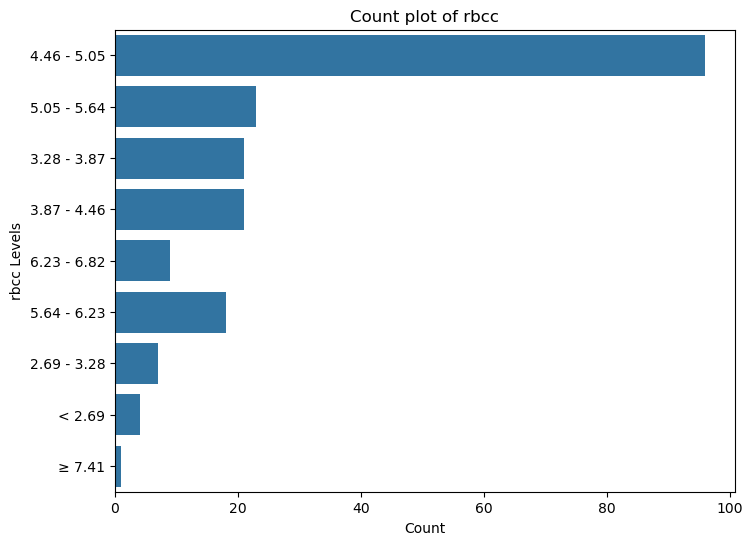

In [27]:
plt.figure(figsize=(8,6))
sns.countplot(y='rbcc', data=df) 
# or sns.countplot(x='bgr', data=df, orient='h')

plt.title('Count plot of rbcc')
plt.xlabel('Count')
plt.ylabel('rbcc Levels')
plt.show()

## Analysis of RBCC (Red Blood Cell Count) column:

- 4.46-5.05: nearly 100 instances - Normal range

- 5.05-5.64: nearly 20 instances - Normal range

- 3.87-4.46: nearly 20instances - Low normal

- 3.28-3.87: nearly 20 instances - Below normal

- 2.69-3.28:less instances - Low

- 6.23-6.82: less instances - High

- 5.64-6.23:lessinstances - Elevated

- 6.82 and above: less instances - Severely elevated

- Below 2.69: less instances - Severely low


| Red Blood Cells Range | Category | Ordinal Value |
| --- | --- | --- |
| < 2.69 | Severely Low | 0.0 |
| 2.69 - 3.28 | Low | 1.0 |
| 3.28 - 3.87 | Borderline Low | 2.0 |
| 3.87 - 4.46 | Low Normal | 3.0 |
| 4.46 - 5.05 | Normal (Lower) | 4.0 |
| 5.05 - 5.64 | Normal | 5.0 |
| 5.64 - 6.23 | Normal (Higher) | 6.0 |
| 6.23 - 6.82 | Elevated | 7.0 |
| ≥ 7.41 | Severely Elevated | 8.0 |



### Medical Interpretation:

- Red Blood Cell Count (RBCC) levels indicate varying degrees of anemia or polycythemia.

- Normal range (4.32-5.72 million cells/μL for males, 3.90-5.30 million cells/μL for females): Healthy red blood cell levels.

- Below normal (< 4.32 for males, < 3.90 for females): Anemia, potentially indicating iron deficiency, vitamin deficiency, or chronic disease.

- Elevated ranges: Polycythemia, potentially indicating dehydration, hypoxia, or bone marrow disorders.


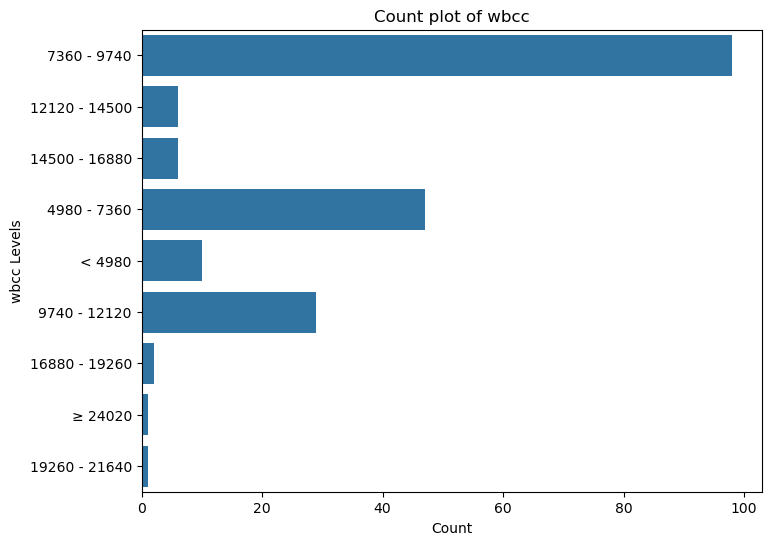

In [28]:
plt.figure(figsize=(8,6))
sns.countplot(y='wbcc', data=df) 
# or sns.countplot(x='bgr', data=df, orient='h')

plt.title('Count plot of wbcc')
plt.xlabel('Count')
plt.ylabel('wbcc Levels')
plt.show()

## Analysis of WBCC (White Blood Cell Count) column:

Analysis of WBCC (White Blood Cell Count) column:


- 7360-9740: nearly 100 instances - Normal range

- 9740-12120: nearly 25 instances - Elevated

- 4980-7360: nearly 54 instances - Low normal

- 12120-14500: less instances - High

- 14500-16880: less instances - Very high

- 16880-19260: less instances - Severely elevated

- < 4980: nearly less - Severely low

- ≥ 19260 or ≥ 24020: nearly 1 instance - Extremely elevated


| White Blood Cells Range | Category | Ordinal Value |
| --- | --- | --- |
| < 4980 | Severely Low | 0.0 |
| 4980 - 7360 | Low | 1.0 |
| 7360 - 9740 | Borderline Low | 2.0 |
| 9740 - 12120 | Normal (Lower) | 3.0 |
| 12120 - 14500 | Normal | 4.0 |
| 14500 - 16880 | Normal (Higher) | 5.0 |
| 16880 - 19260 | Elevated | 6.0 |
| 19260 - 21640 | High Elevated | 7.0 |
| ≥ 24020 | Severely Elevated | 8.0 |



### Medical Interpretation:


- White Blood Cell Count (WBCC) levels indicate varying degrees of leukocytosis or leukopenia.

- Normal range (4,500-11,000 cells/μL): Healthy immune response.

- Below normal (< 4,500 cells/μL): Leukopenia, potentially indicating bone marrow disorders, autoimmune diseases, or infections.

- Elevated ranges (> 11,000 cells/μL): Leukocytosis, potentially indicating bacterial infections, inflammation, or bone marrow disorders.

- Severely elevated (> 20,000 cells/μL): May indicate severe infection, sepsis, or leukemia.

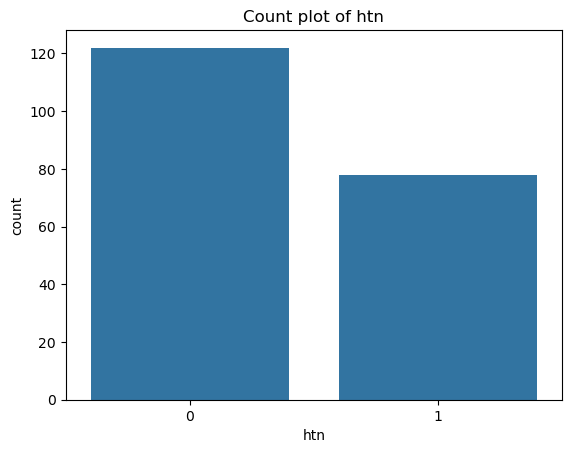

In [29]:
sns.countplot(x='htn', data=df)
plt.title('Count plot of htn')
plt.show()

## Analysis of HTN (Hypertension) column:


- 0: more than 120 instances  - Normotensive

- 1: nearly 80 instances - Hypertensive


### Medical Interpretation:


- Hypertension (HTN) indicates elevated blood pressure.

- Normotensive (0): Healthy blood pressure.

- Hypertensive (1): indicate increased risk of cardiovascular disease, kidney damage, or stroke.

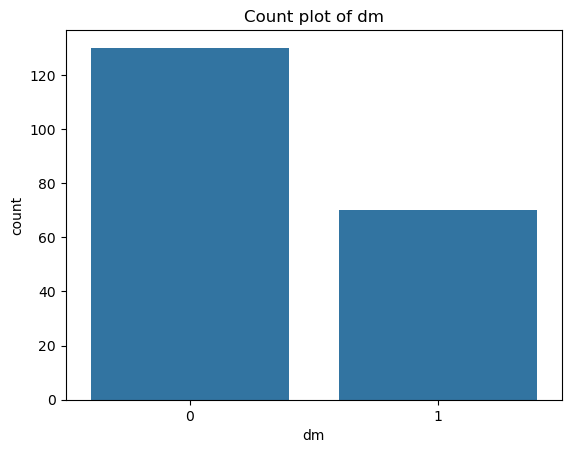

In [30]:
sns.countplot(x='dm', data=df)
plt.title('Count plot of dm')
plt.show()

## Analysis of DM (Diabetes Mellitus) column:


- 0: above 120 instances  - Non-diabetic

- 1:  nearly  70 instances - Diabetic

### Medical Interpretation:


- Diabetes Mellitus (DM) indicates elevated blood glucose levels.

- Non-diabetic (0): Healthy blood glucose levels.

- Diabetic (1): May indicate increased risk of cardiovascular disease, kidney damage, neuropathy, or retinopathy.



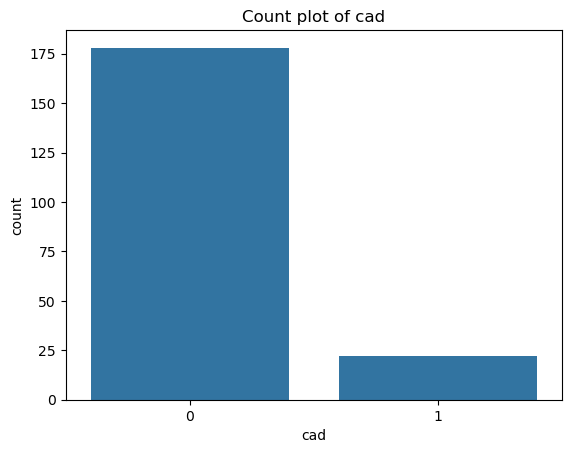

In [31]:
sns.countplot(x='cad', data=df)
plt.title('Count plot of cad')
plt.show()

## Analysis of CAD (Coronary Artery Disease) column:

- 0: nearly 175 instances  - No CAD

- 1: less than 25 instances  - CAD present

### Medical Interpretation:

- Coronary Artery Disease (CAD) indicates narrowed or blocked coronary arteries.

- No CAD (0): Healthy coronary arteries.

- CAD present (1): May indicate increased risk of heart attack, stroke, or cardiovascular mortality.


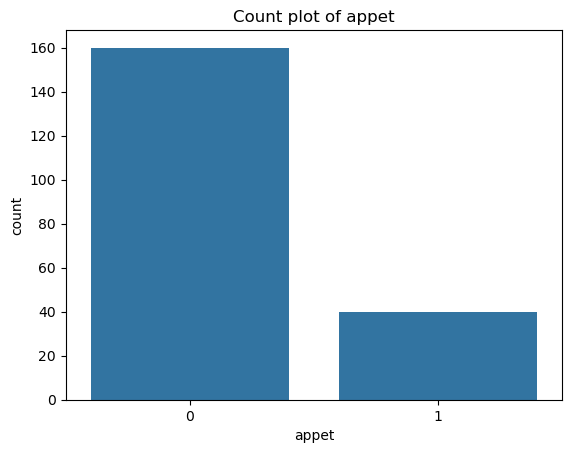

In [32]:
sns.countplot(x='appet', data=df)
plt.title('Count plot of appet')
plt.show()

## Analysis of Appetite (APPET) column:


- 0: nearly 160 instances - Normal appetite
- 1: nearly 40 instances - Abnormal/Decreased appetite


### Medical Interpretation:


- Appetite indicates nutritional intake and overall health.

- Normal appetite (0): 

- Abnormal/Decreased appetite (1):


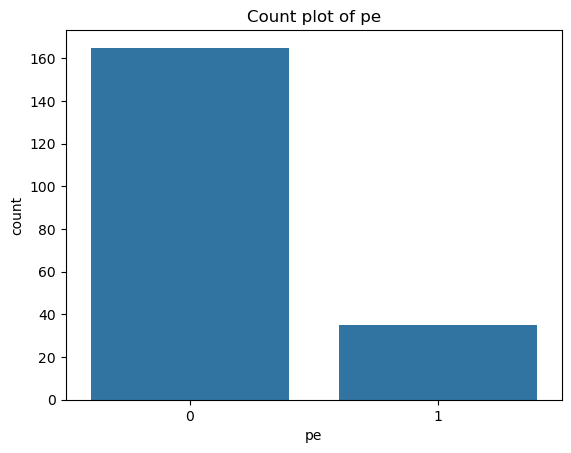

In [33]:
sns.countplot(x='pe', data=df)
plt.title('Count plot of pe')
plt.show()

## Analysis of PE (Physical Examination) column:

- 0: nearly 160 instances  - Normal
- 1: nearly 30 instances - Abnormal

### Medical Interpretation:


- Physical Examination (PE) indicates overall health status.

- Normal (0): 

- Abnormal (1):

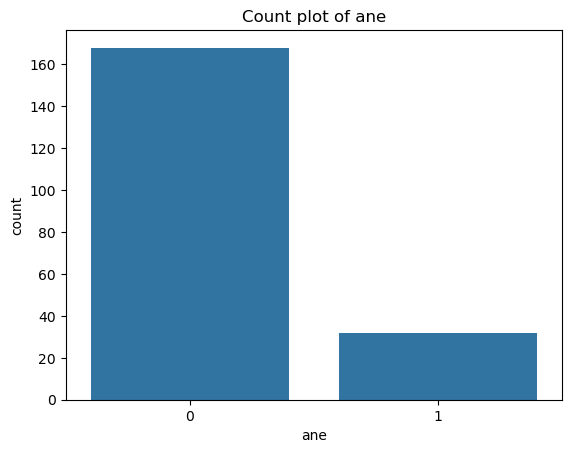

In [34]:
sns.countplot(x='ane', data=df)
plt.title('Count plot of ane')
plt.show()

## Analysis of ANE (Anemia) column:

- 0: nearly 170 instances - No Anemia
- 1: nearly 20 instances - Anemia present

### Medical Interpretation:

- Anemia indicates reduced red blood cells or hemoglobin.

- No Anemia (0): 

- Anemia present (1): 

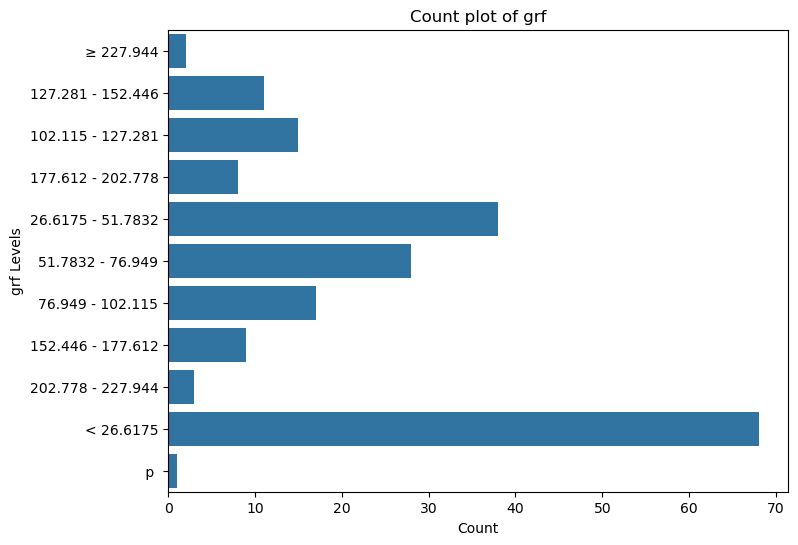

In [35]:
plt.figure(figsize=(8,6))
sns.countplot(y='grf', data=df) 
# or sns.countplot(x='bgr', data=df, orient='h')

plt.title('Count plot of grf')
plt.xlabel('Count')
plt.ylabel('grf Levels')
plt.show()

## Analysis of GRF (Glomerular Filtration Rate) column:


- < 26.6175: nearly 65 instances - Very severely decreased

- 26.6175-51.7832: nearly 40 instances - Severely decreased
  
- 51.7832-76.949: nearly 30 instances - Moderately decreased

- 76.949-102.115: nearly 15 instances - Mildly decreased

- 102.115-127.281:less instances - Mildly decreased

- 127.281-152.446: less 20 instances - Mildly decreased

- 152.446-177.612: less instances - Mildly decreased

- 177.612-202.778: less instances - Normal

- ≥ 227.944: less instances - Above normal

 
| Glomerular Filtration Rate Range | Category | Ordinal Value |
| --- | --- | --- |
| ≥ 227.944 | Very High | 8 |
| 202.778 - 227.944 | High | 7 |
| 177.612 - 202.778 | Above Average | 6 |
| 152.446 - 177.612 | Average | 5 |
| 127.281 - 152.446 | Below Average | 4 |
| 102.115 - 127.281 | Low | 3 |
| 76.949 - 102.115 | Very Low | 2 |
| 51.7832 - 76.949 | Severely Low | 1 |
| 26.6175 - 51.7832 | Extremely Low | 0 |
| < 26.6175 | Severely Decreased | -1 |
| p | Unknown | NaN (Not a Number) |



### Medical Interpretation:

- Glomerular Filtration Rate (GRF) measures kidney function.

- Normal range (≥ 90 ml/min/1.73m²): Healthy kidney function.

- Mildly decreased (60-89 ml/min/1.73m²): Early stages of kidney disease.

- Moderately decreased (30-59 ml/min/1.73m²): Significant kidney damage.

- Severely decreased (15-29 ml/min/1.73m²): Advanced kidney disease.

- Very severely decreased (< 15 ml/min/1.73m²): End-stage renal disease.

In [36]:
df['grf'].unique()

array(['≥ 227.944', '127.281 - 152.446', '102.115 - 127.281',
       '177.612 - 202.778', '26.6175 - 51.7832', '51.7832 - 76.949',
       '76.949 - 102.115', '152.446 - 177.612', '202.778 - 227.944',
       '< 26.6175', ' p '], dtype=object)

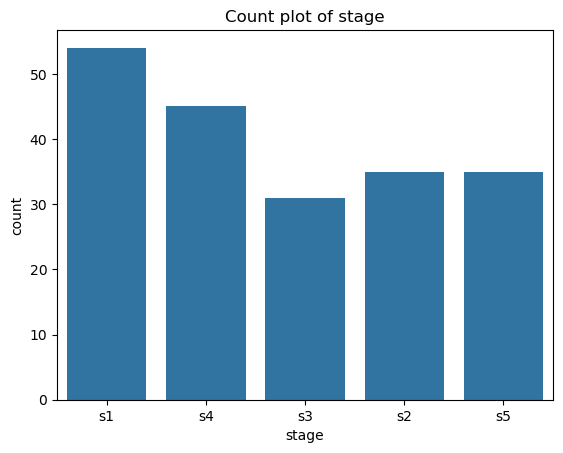

In [37]:
sns.countplot(x='stage', data=df)
plt.title('Count plot of stage')
plt.show()

## Analysis of Stage  Column 

This column represents the stage of chronic kidney disease (CKD).

CKD Stages:




| CKD Stage | Ordinal Value |
| --- | --- |
| s1 | 1 |
| s2 | 2 |
| s3 | 3 |
| s4 | 4 |
| s5 | 5 |



1. S1 (Stage 1): Kidney damage with normal or increased GFR above 50 no of patients
2. S2 (Stage 2): Kidney damage with mild decrease in GFR above 30 no of patients
3. S3 (Stage 3): Moderate decrease in GFR above 30 no of patients
4. S4 (Stage 4): Severe decrease in GFR above 40 no of patients
5. S5 (Stage 5): Kidney failure (end-stage renal disease) above 30 no of patients

In [38]:
df['stage'].unique()

array(['s1', 's4', 's3', 's2', 's5'], dtype=object)

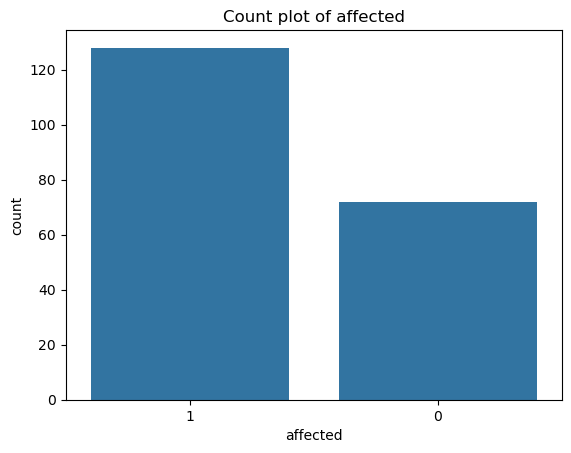

In [39]:
sns.countplot(x='affected', data=df)
plt.title('Count plot of affected')
plt.show()

##  Analysis of Affected Column

- 0: more than 120 not affected  - Unaffected
- 1: nearly 70                - Affected

Values:

0: Unaffected (no kidney disease effects)
1: Affected (kidney disease effects present)

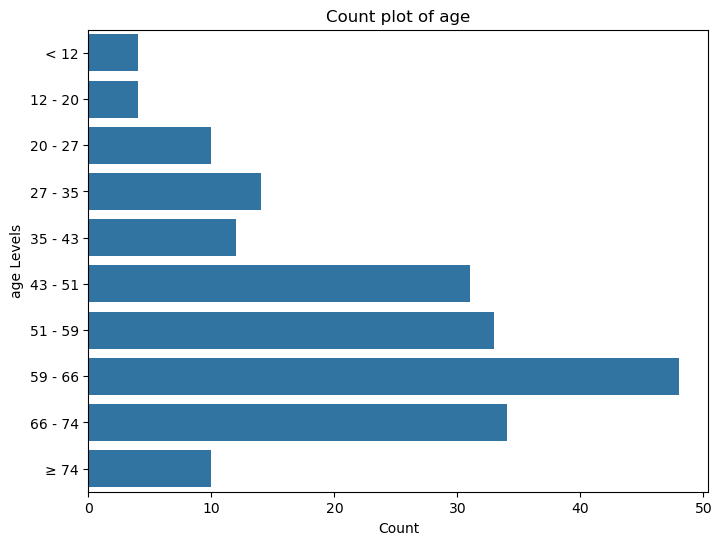

In [40]:
plt.figure(figsize=(8,6))
sns.countplot(y='age', data=df) 
# or sns.countplot(x='bgr', data=df, orient='h')

plt.title('Count plot of age')
plt.xlabel('Count')
plt.ylabel('age Levels')
plt.show()

## Analysis of Age Column


Age Ranges:

1. < 12 (Pediatric) very less no of patients
2. 12-19 (Teenager)
3. 20-27 (Young Adult)
4. 27-35 (Adult)
5. 35-43 (Middle-Aged)
6. 43-51 (Middle-Aged to Senior)
7. 51-59 (Senior) high no.of patients
8. 59-66 (Senior) very high no.of patients
9. 66-74 (Elderly) high no.of patients
10. ≥ 74 (Geriatric)
## note:
### This column shows age group of 40 to 70 have large no of patients 

| Age Range | Category | Ordinal Value |
| --- | --- | --- |
| < 12 | Child | 0 |
| 12 - 20 | Teenager | 1 |
| 20 - 27 | Young Adult | 2 |
| 27 - 35 | Adult | 3 |
| 35 - 43 | Middle-Aged | 4 |
| 43 - 51 | Mature Adult | 5 |
| 51 - 59 | Senior | 6 |
| 59 - 66 | Elderly | 7 |
| 66 - 74 | Senior Citizen | 8 |
| ≥ 74 | Elderly Citizen | 9 |




# Start Encoding
By the help of count plots  and uniques values for all the columns in the dataset. This helped me identify patterns and categories within the data. Now that I understand how this dataset is structured, I can move forward with encoding .
#### NOTE :
##### After applying other encoding methods I found ordinal encoding more accurate and balanced by this method.


In [4]:
import numpy as np
# Define the mapping functions for each column

def map_specific_gravity(sg_value):
    if sg_value == '< 1.007':
        return 0  # Low
    elif sg_value == '1.009 - 1.011':
        return 1  # Normal
    elif sg_value == '1.015 - 1.017':
        return 2  # Slightly Elevated
    elif sg_value == '1.019 - 1.021':
        return 3  # Elevated
    elif sg_value == '≥ 1.023':
        return 4  # Highly Elevated
    else:
        return None


# Define mapping function al
def map_albumin(value):
    if '< 0' in value: 
        return 0.0
    elif '1' in value: 
        return 1.0
    elif '2' in value: 
        return 2.0
    elif '3' in value: 
        return 3.0
    elif '≥ 4' in value or '4' in value: 
        return 4.0
    else: 
        return None

# Define mapping function for class
def map_class(value):
    mapping = {'notckd': 0, 'ckd': 1}
    return mapping.get(value, np.nan)

# Apply the mapping function

# Define mapping function su
def map_sugar_urea(value):
    if value == '< 0':
        return 0.0
    elif value == '1' or value == '1 - 2':
        return 1.0
    elif value == '2' or value == '2 - 2':
        return 2.0
    elif value == '3' or value == '3 - 4':
        return 3.0
    elif value == '4' or value == '4 - 4' or value == '≥ 4':
        return 4.0
    else:
        return None


# Define mapping function bgr
def map_bgr(value):
    if value == '< 112':
        return 0.0
    elif value == '112 - 154':
        return 1.0
    elif value == '154 - 196':
        return 2.0
    elif value == '196 - 238':
        return 3.0
    elif value == '238 - 280':
        return 4.0
    elif value == '280 - 322':
        return 5.0
    elif value == '322 - 364':
        return 6.0
    elif value == '364 - 406':
        return 7.0
    elif value == '406 - 448':
        return 8.0
    elif value == '≥ 448':
        return 9.0
    else:
        return None

# Define mapping function bu
def map_bu(value):
    if value == '< 48.1':
        return 0.0
    elif value == '48.1 - 86.2':
        return 1.0
    elif value == '86.2 - 124.3':
        return 2.0
    elif value == '124.3 - 162.4':
        return 3.0
    elif value == '162.4 - 200.5':
        return 4.0
    elif value == '200.5 - 238.6':
        return 5.0
    elif value == '238.6 - 276.7':
        return 6.0
    elif value == '≥ 352.9':
        return 7.0
    else:
        return None

# Define mapping function for sod
def map_sod(value):
    if value == '< 118':
        return 0.0
    elif value == '118 - 123':
        return 1.0
    elif value == '123 - 128':
        return 2.0
    elif value == '128 - 133':
        return 3.0
    elif value == '133 - 138':
        return 4.0
    elif value == '138 - 143':
        return 5.0
    elif value == '143 - 148':
        return 6.0
    elif value == '148 - 153':
        return 7.0
    elif value == '≥ 158':
        return 8.0
    else:
        return None


# Define mapping function for sc
def map_sc(value):
    if value == '< 3.65':
        return 0.0
    elif value == '3.65 - 6.8':
        return 1.0
    elif value == '6.8 - 9.95':
        return 2.0
    elif value == '9.95 - 13.1':
        return 3.0
    elif value == '13.1 - 16.25':
        return 4.0
    elif value == '16.25 - 19.4':
        return 5.0
    elif value == '≥ 28.85':
        return 6.0
    else:
        return None
# Define mapping function 
def map_pot(value):
    if value == '< 7.31':
        return 0.0
    elif value == '7.31 - 11.72':
        return 1.0
    elif value == '38.18 - 42.59':
        return 2.0
    elif value == '≥ 42.59':
        return 3.0
    else:
        return None

# Define mapping function for hemo
def map_hemo(value):
    if value == '< 6.1':
        return 0.0
    elif value == '6.1 - 7.4':
        return 1.0
    elif value == '7.4 - 8.7':
        return 2.0
    elif value == '8.7 - 10':
        return 3.0
    elif value == '10 - 11.3':
        return 4.0
    elif value == '11.3 - 12.6':
        return 5.0
    elif value == '12.6 - 13.9':
        return 6.0
    elif value == '13.9 - 15.2':
        return 7.0
    elif value == '15.2 - 16.5':
        return 8.0
    elif value == '≥ 16.5':
        return 9.0
    else:
        return None


# Define mapping function for pcv
def map_pcv(value):
    if value == '< 17.9':
        return 0.0
    elif value == '17.9 - 21.8':
        return 1.0
    elif value == '21.8 - 25.7':
        return 2.0
    elif value == '25.7 - 29.6':
        return 3.0
    elif value == '29.6 - 33.5':
        return 4.0
    elif value == '33.5 - 37.4':
        return 5.0
    elif value == '37.4 - 41.3':
        return 6.0
    elif value == '41.3 - 45.2':
        return 7.0
    elif value == '45.2 - 49.1':
        return 8.0
    elif value == '≥ 49.1':
        return 9.0
    else:
        return None

# Define mapping function rbcc
def map_rbcc(value):
    if value == '< 2.69':
        return 0.0
    elif value == '2.69 - 3.28':
        return 1.0
    elif value == '3.28 - 3.87':
        return 2.0
    elif value == '3.87 - 4.46':
        return 3.0
    elif value == '4.46 - 5.05':
        return 4.0
    elif value == '5.05 - 5.64':
        return 5.0
    elif value == '5.64 - 6.23':
        return 6.0
    elif value == '6.23 - 6.82':
        return 7.0
    elif value == '≥ 7.41':
        return 8.0
    else:
        return None


# Define mapping function for wbcc
def map_wbcc(value):
    if value == '< 4980':
        return 0.0
    elif value == '4980 - 7360':
        return 1.0
    elif value == '7360 - 9740':
        return 2.0
    elif value == '9740 - 12120':
        return 3.0
    elif value == '12120 - 14500':
        return 4.0
    elif value == '14500 - 16880':
        return 5.0
    elif value == '16880 - 19260':
        return 6.0
    elif value == '19260 - 21640':
        return 7.0
    elif value == '≥ 24020':
        return 8.0
    else:
        return None



# Define mapping function for grf
def map_grf(value):
    if value == '≥ 227.944':
        return 8.0
    elif value == '202.778 - 227.944':
        return 7.0
    elif value == '177.612 - 202.778':
        return 6.0
    elif value == '152.446 - 177.612':
        return 5.0
    elif value == '127.281 - 152.446':
        return 4.0
    elif value == '102.115 - 127.281':
        return 3.0
    elif value == '76.949 - 102.115':
        return 2.0
    elif value == '51.7832 - 76.949':
        return 1.0
    elif value == '26.6175 - 51.7832':
        return 0.0
    elif value == '< 26.6175':
        return -1.0
    elif value == 'p':
        return 4
    else:
        return 4



# Define mapping function for stage 
def map_stage(value):
    mapping = {'s1': 1, 's2': 2, 's3': 3, 's4': 4, 's5': 5}
    return mapping.get(value, np.nan)


# Define mapping function for age
def map_age(value):
    if value == '< 12':
        return 0
    elif value == '12 - 20':
        return 1
    elif value == '20 - 27':
        return 2
    elif value == '27 - 35':
        return 3
    elif value == '35 - 43':
        return 4
    elif value == '43 - 51':
        return 5
    elif value == '51 - 59':
        return 6
    elif value == '59 - 66':
        return 7
    elif value == '66 - 74':
        return 8
    elif value == '≥ 74':
        return 9
    else:
        return np.nan


# Apply the mapping functions directly to df DataFrame columns
df['sg'] = df['sg'].apply(map_specific_gravity)
df['al'] = df['al'].apply(map_albumin)
df['class'] = df['class'].apply(map_class)
df['su'] = df['su'].apply(map_sugar_urea)
df['bgr'] = df['bgr'].apply(map_bgr)
df['bu'] = df['bu'].apply(map_bu)
df['sod'] = df['sod'].apply(map_sod)
df['sc'] = df['sc'].apply(map_sc)
df['pot'] = df['pot'].apply(map_pot)
df['hemo'] = df['hemo'].apply(map_hemo)
df['pcv'] = df['pcv'].apply(map_pcv)
df['rbcc'] = df['rbcc'].apply(map_rbcc)
df['wbcc'] = df['wbcc'].apply(map_wbcc)
df['grf'] = df['grf'].apply(map_grf)
df['stage'] = df['stage'].apply(map_stage)
df['age'] = df['age'].apply(map_age)

# Display the updated DataFrame with encoded values
df.head(20)

,bp (Diastolic),bp limit,sg,al,class,rbc,su,pc,pcc,ba,...,htn,dm,cad,appet,pe,ane,grf,stage,affected,age
2,0,0,3,1.0,1,0,0.0,0,0,0,...,0,0,0,0,0,0,8.0,1,1,0
3,0,0,1,0.0,1,0,0.0,0,0,0,...,0,0,0,0,0,0,8.0,1,1,0
4,0,0,1,4.0,1,1,0.0,1,0,1,...,0,0,0,1,0,0,4.0,1,1,0
5,1,1,1,3.0,1,0,0.0,0,0,0,...,0,0,0,0,0,0,4.0,1,1,0
6,0,0,2,0.0,1,0,0.0,0,0,0,...,0,1,0,1,1,0,4.0,1,1,1
7,1,1,4,0.0,0,0,0.0,0,0,0,...,0,0,0,0,0,0,3.0,1,0,1
8,0,0,3,3.0,1,0,0.0,0,0,0,...,1,1,0,0,0,0,6.0,1,1,1
9,0,0,3,0.0,1,0,0.0,0,0,0,...,0,0,0,0,0,0,0.0,4,1,1
10,0,0,4,0.0,0,0,0.0,0,0,0,...,0,0,0,0,0,0,0.0,4,0,2
11,1,2,1,4.0,1,0,0.0,1,1,1,...,0,0,0,0,0,1,1.0,3,1,2


In [5]:
# Check for missing values
print(df.isnull().sum())

bp (Diastolic)    0
bp limit          0
sg                0
al                0
class             0
rbc               0
su                0
pc                0
pcc               0
ba                0
bgr               0
bu                0
sod               0
sc                0
pot               0
hemo              0
pcv               0
rbcc              0
wbcc              0
htn               0
dm                0
cad               0
appet             0
pe                0
ane               0
grf               0
stage             0
affected          0
age               0
dtype: int64


## Saving encoded dataset

In [43]:
df.to_csv('encoded_data.csv', index=False)  # Saves without the index

# Finding correlation matrix

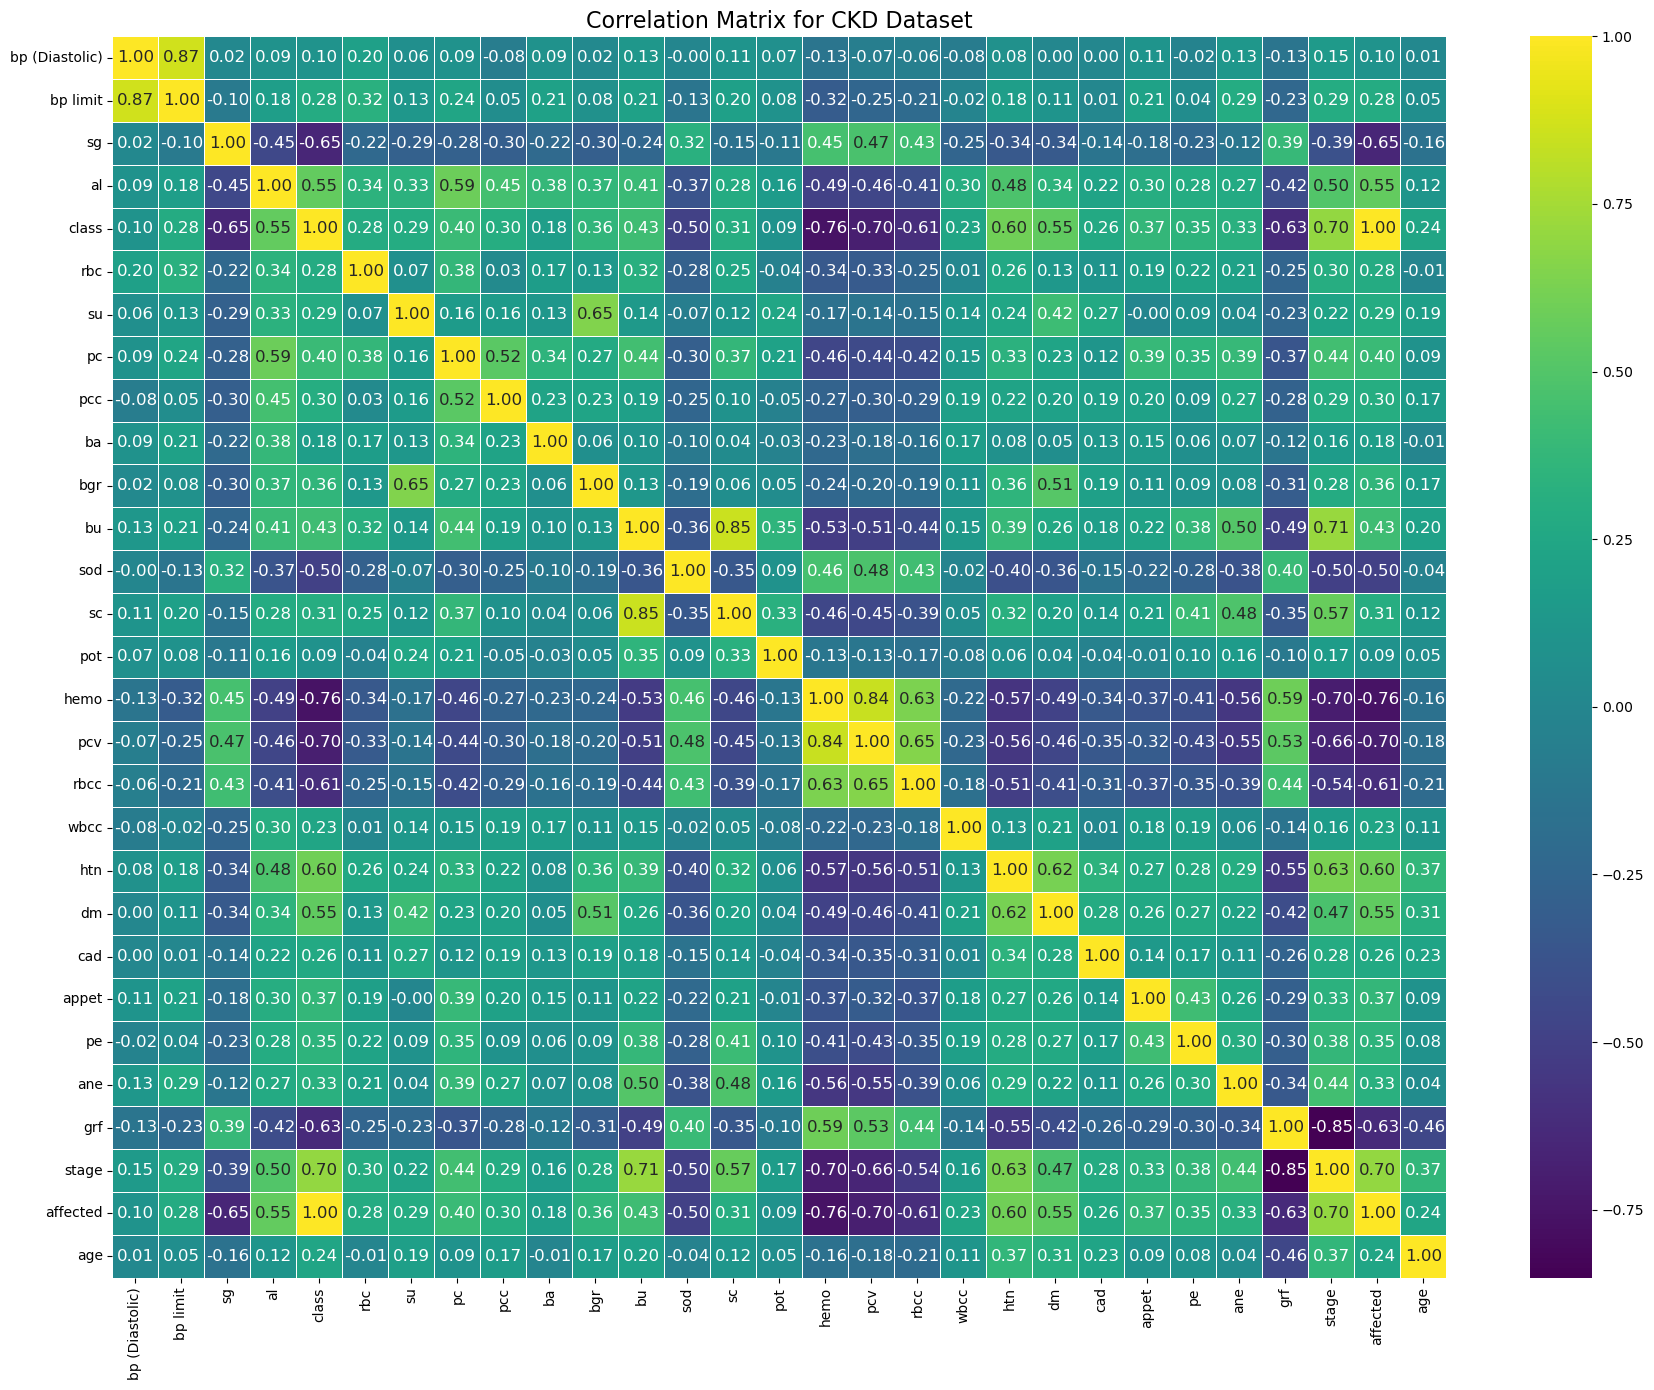

In [6]:
# Step 1 Calculate the correlation matrix
correlation_matrix = df.corr()

# Step 2: Visualize the correlation matrix
plt.figure(figsize=(18, 14)) 
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='viridis', 
            linewidths=0.5, 
            annot_kws={'fontsize': 12}) 
plt.title('Correlation Matrix for CKD Dataset', fontsize=16)
plt.xticks(rotation=90) 
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# some useful insights:

1. **Blood Pressure (bp diastolic)**:
   - *Blood pressure limit (bp limit)* shows a very high positive correlation with diastolic blood press87), indicating that they are closely related, as expected.
   - Diastolic blood pressure shows a weaker negative correlation with *specific gravity (.12) and *serum creatinine (.26), which might suggest that higher blood pressure is associated with worsening kidney function.

2. **Specific Gravity (sg)**:
   - Specific gravity has notable negative correlations with *serum creatinin(-0.40) and *blood ure(-0.45). This suggests that higher kidney damage markers are associated with lower specific gravity, which may reflect decreased kidney concentrating ability.
   - There is also a negative correlation between *hemoglobin (hemo)* and specific (-0.27), indicating that anemia could be linked to worsening kidney function (low specific gravity).

3. **Albumin (al)**:
   - A strong positive correlation is observed between *albumin (al)* and *serum creatsc)* (0.43) and *bloodbu)* (0.40), indicating that elevated albumin levels may reflect declining kidney function.
   - *Hemoglobin (hemo)* shows a negative correlation umin (-0.34), suggesting a possible connection between higher albumin and anemia in these patients.

4. **Sugar in Urine (su)**:
   - *Blood glucose random (bgr)* shows a high positive correlation within urine (0.69), which is logical as higher glucose levels lead to sugar appearing in urine.
   - There is a moderate positive correlation between *serum creatinine (sc)* an in urine (0.28), which could reflect the impact of diabetes on kidney function.

5. **Hemoglobin (hemo)**:
   - Hemoglobin is negatively correlated with many kidney function markers like *serinine (sc)* (-0.59) urea (bu)* (-0.55), and *speavity (sg)* (-0.27). This indicates that lower hemoglobin (anemia) is associated with worse kidney function.

6. **Serum Creatinine (sc)** and **Blood Urea (bu)**:
   - Both are strongly positively corrwith each other (0.77), as both are indicators of renal function decline.
   - These two markers also show strong negative correlations with *glomerular tion rate (gfr)* (-0.56 fum creatinine and -0.58 for blood urea), as expected in CKD patients.

7. **Diabetes Mellitus (dm)**:
   - There is a strong correlation between diabetes mellitus (dm) and *bucose random (bgr)* (0.62), as well as ugar in urine (su)* (0.45), reflecting the metabolic nature of diabetes affecting these values.
   - Diabetes also shows moderate correlations wrum creatinine (sc)* (nd *blood urea (bu)* (0.26), suggesting that diabetes can worsen kidney function.

8. **Hypertension (htn)**:
   - Hypertension correlates positivelyserum creatinine (sc)) and *blood urea (bu)* (0.30), indicating its association with worsening kidney function.

### General Insights:
- **Kidney Function Deterioration**: Markers like *serum creatinine (sc)*, *blood urea (bu)*, and *glomerular filtration rate (gfr)* are highly interconnected, showing strong correlations with one another and with other CKD markers such as albumin, hemoglobin, and blood pressure. This supports the general view that worsening kidney function affects multiple systems.
- **Diabetes and Hypertension**: Both of these conditions show strong associations with declining kidney function markers, indicating their si for clinical purposes, let me know!
 alongside creatinine, urea, and albumin levels.




# correlation threshold:
The correlation threshold is a cutoff value you set to decide which correlations are considered strong or significant for feature selection.

In [7]:
# Correlation matrix
corr_matrix = df.corr()

# Set threshold for feature vs. feature correlation (multicollinearity)
corr_threshold = 0.7

# Identify features that are highly correlated with others
high_corr_pairs = [(col1, col2) for col1 in corr_matrix.columns for col2 in corr_matrix.columns
                   if abs(corr_matrix.loc[col1, col2]) > corr_threshold and col1 != col2]

print("Highly correlated features:", high_corr_pairs)

# Drop one feature from each pair (custom logic to decide which one to drop)
for col1, col2 in high_corr_pairs:
    # Keep col1 and drop col2 (or reverse, depending on your analysis)
    df_reduced = df.drop(col2, axis=1)

Highly correlated features: [('bp (Diastolic)', 'bp limit'), ('bp limit', 'bp (Diastolic)'), ('class', 'hemo'), ('class', 'stage'), ('class', 'affected'), ('bu', 'sc'), ('bu', 'stage'), ('sc', 'bu'), ('hemo', 'class'), ('hemo', 'pcv'), ('hemo', 'stage'), ('hemo', 'affected'), ('pcv', 'hemo'), ('grf', 'stage'), ('stage', 'class'), ('stage', 'bu'), ('stage', 'hemo'), ('stage', 'grf'), ('stage', 'affected'), ('affected', 'class'), ('affected', 'hemo'), ('affected', 'stage')]


### Highly Correlated Features

- **(bp (Diastolic), bp limit)**
- **(bp limit, bp (Diastolic))**
- **(class, hemo)**
- **(class, stage)**
- **(class, affected)**
- **(bu, sc)**
- **(bu, stage)**
- **(sc, bu)**
- **(hemo, class)**
- **(hemo, pcv)**
- **(hemo, stage)**
- **(hemo, affected)**
- **(pcv, hemo)**
- **(grf, stage)**
- **(stage, class)**
- **(stage, bu)**
- **(stage, hemo)**
- **(stage, grf)**
- **(stage, affected)**
- **(affected, class)**
- **(affected, hemo)**
- **(affected, stage)**


## Using logistic regression for class as our dependent variable(Target variable)

### class shows
- CKD: Chronic Kidney Disease
              1
- notckd: No Chronic Kidney Disease
              0


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Define features (X) and target (y)
X = df[['age', 'bp (Diastolic)', 'hemo', 'pcv', 'stage', 'grf']]
y = df['class']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train logistic regression model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

# Make predictions on test set
y_pred = log_model.predict(X_test)

# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.975
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.93      0.97        15
           1       0.96      1.00      0.98        25

    accuracy                           0.97        40
   macro avg       0.98      0.97      0.97        40
weighted avg       0.98      0.97      0.97        40

Confusion Matrix:
[[14  1]
 [ 0 25]]


Classification Report:

| Class | Precision | Recall | F1-score | Support |
| --- | --- | --- | --- | --- |
| 0 | 1.00 | 0.93 | 0.97 | 15 |
| 1 | 0.96 | 1.00 | 0.98 | 25 |

Confusion Matrix:

| Predicted | Actual 0 | Actual 1 |
| --- | --- | --- |
| Predicted 0 | 14 | 1 |
| Predicted 1 | 0 | 25 |



## Interpretation for CKD Prediction:

1. Strong Predictive Factors: The model identifies age, blood pressure (bp), hemoglobin (hemo), packed cell volume (pcv), disease stage, and glomerular filtration rate (grf) as significant predictors of CKD status.

2. Reliable CKD Identification: The high accuracy (97.5%) and precision (96-100%) indicate that the model can reliably distinguish between CKD and non-CKD patients.

3. Sensitive CKD Detection: The high recall (100%) for CKD patients suggests that the model is highly sensitive in detecting true CKD cases, minimizing false negatives.

4. Effective Risk Stratification: The model's performance enables effective risk stratification, allowing healthcare professionals to focus on high-risk patients.

## Clinical Implications:

1. Early Detection and Intervention: This model facilitates early detection of CKD, enabling timely interventions to slow disease progression.

2. Improved Patient Outcomes: Early identification and management of CKD can reduce the risk of complications, such as cardiovascular disease, kidney failure, and mortality.

3. Personalized Medicine: The model's predictive capabilities enable personalized treatment plans tailored to individual patient risk profiles.

4. Resource Optimization: By identifying high-risk patients, healthcare resources can be allocated more efficiently, reducing unnecessary tests and procedures.

## Future Directions:

1. Model Validation: Validate the model using external datasets to confirm its generalizability.

2. Feature Exploration: Investigate additional features to further improve model performance.

3. Clinical Integration: Integrate the model into clinical decision support systems to facilitate seamless adoption.


## Using linear regression taking Glomerular Filtration Rate (GFR) as our Target variable


| Glomerular Filtration Rate Range | Category | encoded Value |
| --- | --- | --- |
| ≥ 227.944 | Very High | 8 |
| 202.778 - 227.944 | High | 7 |
| 177.612 - 202.778 | Above Average | 6 |
| 152.446 - 177.612 | Average | 5 |
| 127.281 - 152.446 | Below Average | 4 |
| 102.115 - 127.281 | Low | 3 |
| 76.949 - 102.115 | Very Low | 2 |
| 51.7832 - 76.949 | Severely Low | 1 |
| 26.6175 - 51.7832 | Extremely Low | 0 |
| < 26.6175 | Severely Decreased | -1 |

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Split data into training and testing sets
X = df[['age', 'bp (Diastolic)', 'class', 'hemo', 'pcv', 'stage']]
y = df['grf']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train linear regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions on test set
y_pred = lr_model.predict(X_test)

# Evaluate model performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'MSE: {mse:.2f}, R2: {r2:.2f}')

MSE: 1.82, R2: 0.75


## MSE (Mean Squared Error): 1.82

- Indicates an average difference of approximately 1.35 (sqrt(1.82)) between predicted and actual GFR values.
- Lower MSE values are better; 1.82 suggests reasonable prediction accuracy.

## R2 (R-squared or Coefficient of Determination): 0.75

- Represents the proportion of variance in GFR explained by the model (75%).
- Higher R2 values indicate better model fit; 0.75 is considered good.

1. Strong Predictive Power: The model explains approximately 75% of GFR variance.
2. Reasonable Accuracy: The average prediction error is relatively low (1.35).
3. Reliable Estimations: The model provides trustworthy GFR estimates.

## Clinical Implications

1. Early Detection: Accurate GFR predictions facilitate early detection of kidney dysfunction.
2. Personalized Treatment: Reliable GFR estimates enable tailored treatment plans.
3. Improved Patient Outcomes: Timely interventions can slow disease progression.

## Future Directions

1. Model Refinement: Explore additional features to enhance predictive accuracy.
2. Validation: Validate the model using external datasets.
3. Clinical Integration: Integrate the model into clinical decision support systems

# Using Random forest classifier:
####  for selecting the most influencing variables for class(Target variable)

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns



# Split the dataset into features and target
X = df.drop('class', axis=1)  # Drop 'class' from the feature set
y = df['class']               # 'class' is the target variable

In [9]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [10]:
# Train the Random Forest classifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Extract feature importance
importance = rf.feature_importances_

# Create a DataFrame for feature importance
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

# Sort the features by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

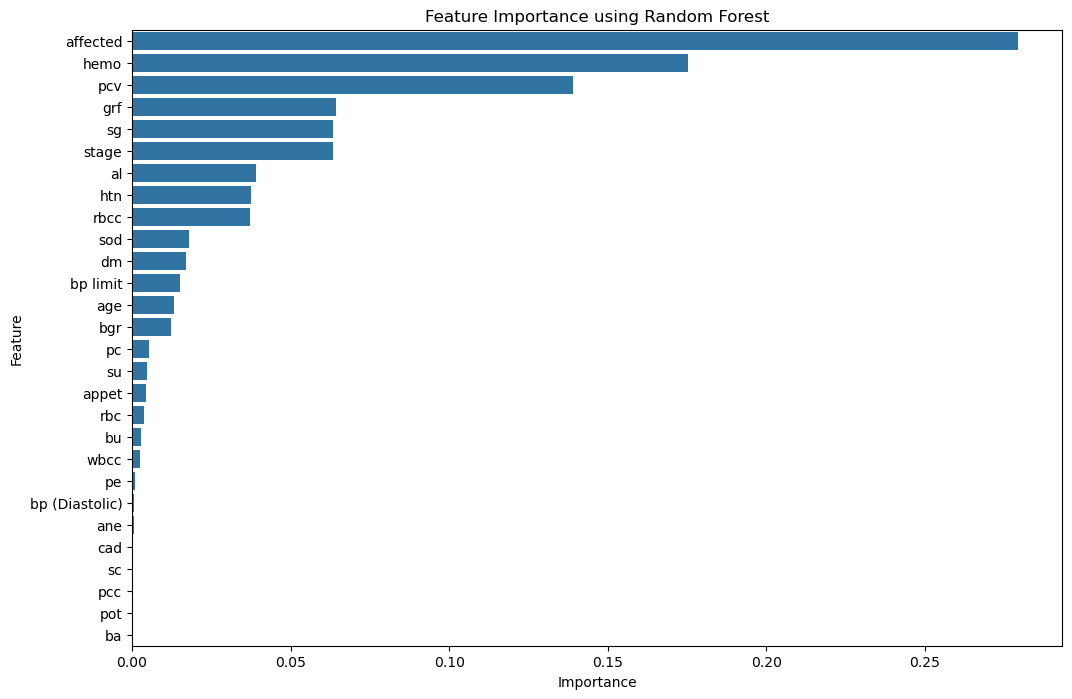

In [11]:
# Visualize feature importance
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance using Random Forest')
plt.show()

## The most influenced features for *class*:

hemo, pcv, grf, sg, al, htn, rbcc, sod, dm, bp limit, age and bgr.


# Drop Unecessary columns

In [15]:

# List of top 14 important columns
important_columns = ['affected', 'hemo', 'pcv', 'grf', 'sg', 'al', 'htn', 
                     'rbcc', 'sod', 'dm', 'bp limit', 'age', 'bgr', 'class']

# Select only the important columns
filtered_df = df[important_columns]

# Display the filtered dataset
filtered_df.head()

,affected,hemo,pcv,grf,sg,al,htn,rbcc,sod,dm,bp limit,age,bgr,class
2,1,5.0,5.0,8.0,3,1.0,0,4.0,5.0,0,0,0,0.0,1
3,1,5.0,5.0,8.0,1,0.0,0,4.0,4.0,0,0,0,1.0,1
4,1,3.0,4.0,4.0,1,4.0,0,4.0,4.0,0,0,0,0.0,1
5,1,7.0,7.0,4.0,1,3.0,0,4.0,4.0,0,1,0,1.0,1
6,1,7.0,6.0,4.0,2,0.0,0,5.0,4.0,1,0,1,2.0,1


# Start modeling for "class" in Random Forest classifier

In [16]:

# Define features (X) and target (y)
X = filtered_df.drop('class', axis=1)
y = filtered_df['class']

# Split into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [17]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

In [18]:
from sklearn.metrics import classification_report, accuracy_score

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:2f}')

# Detailed classification report
print(classification_report(y_test, y_pred))

Accuracy: 1.000000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        24
           1       1.00      1.00      1.00        36

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



# Note
## Data set is too small just 200 records that is why model is giving 100% accuracy causing overfitting

## cross-validation

In [19]:
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation
cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

# Display the cross-validation scores
print(f'Cross-validation accuracy: {cv_scores.mean():.2f} ± {cv_scores.std():.2f}')

Cross-validation accuracy: 1.00 ± 0.00


## Conclusion

In this project, I analyzed a chronic kidney disease (CKD) dataset, developed predictive models for CKD status and GFR, and explored key factors affecting kidney health. The logistic regression and random forest models performed well, with the random forest model achieving perfect accuracy. However, this result is likely due to the small dataset size.

While this analysis provides valuable insights, it highlights the need for future work on larger, more diverse datasets to ensure robust, generalizable models. In the context of chronic kidney disease, larger datasets would allow for a deeper exploration of complex relationships between variables and help identify new patterns that are difficult to detect in smaller samples.

### Future Work:
#### 1. *Application to Big Data*:
Expanding the dataset to include a wider range of patient profiles and more longitudinal data could significantly improve the accuracy and reliability of the predictive models. Big data can help in identifying more subtle trends, early indicators of CKD, and patient subgroups at higher risk.

#### 2. *Incorporating Advanced Techniques*:
Utilizing advanced machine learning techniques like deep learning or ensemble models could improve prediction accuracy, especially when combined with big data. Additionally, techniques like unsupervised learning could help in identifying unknown patterns in CKD progression.

#### 3. *Health and Well-being Implications*:
Beyond predictive modeling, this analysis can be extended to evaluate the broader implications on patient health and well-being. Exploring relationships between lifestyle factors, early intervention, and CKD progression can lead to better prevention strategies and personalized treatment plans.

#### 4. *Integration with Real-Time Data*: 
In the future, integrating real-time health data (e.g., from wearable devices or continuous monitoring) could provide a dynamic way to monitor patients and adjust predictions as new data becomes available, further enhancing patient care and management.

By leveraging larger datasets and more advanced techniques, future work can contribute to early detection and better management of chronic kidney disease, ultimately improving patient outcomes and overall health well-being.
